In [1]:
# ===============================
# 1. IMPORTAR BIBLIOTECAS
# ===============================

import requests
import pandas as pd
import json

# ===============================
# 2. CARREGAR DADOS DA API (JSON)
# ===============================

URL = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

response = requests.get(URL)

# Verificação de sucesso
print("Status Code:", response.status_code)

data = response.json()

# Visualizar estrutura inicial
print("Tipo de dado:", type(data))
print("Total de registros:", len(data))

# ===============================
# 3. CONVERTER PARA DATAFRAME
# ===============================

df = pd.json_normalize(data)

print("Dimensão do DataFrame:", df.shape)
df.head()

Status Code: 200
Tipo de dado: <class 'list'>
Total de registros: 7267
Dimensão do DataFrame: (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [3]:
df.describe(include='all')

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
count,7267,7267,7267,7267.000000,7267,7267,7267.000000,7267,7267,7267,...,7267,7267,7267,7267,7267,7267,7267,7267,7267.000000,7267
unique,7267,3,2,NaN,2,2,NaN,2,3,3,...,3,3,3,3,3,3,2,4,NaN,6531
top,9995-HOTOH,No,Male,NaN,No,No,NaN,Yes,No,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2
freq,1,5174,3675,NaN,3749,5086,NaN,6560,3495,3198,...,3182,3195,3582,2896,2870,4005,4311,2445,NaN,11
mean,NaN,NaN,NaN,0.162653,NaN,NaN,32.346498,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.720098,NaN
std,NaN,NaN,NaN,0.369074,NaN,NaN,24.571773,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.129572,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN
25%,NaN,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.425000,NaN
50%,NaN,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.300000,NaN
75%,NaN,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.875000,NaN


In [4]:
df.isnull().sum().sort_values(ascending=False)

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [5]:
# Listar colunas
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [7]:
# Tipos organizados
df.dtypes.value_counts()

,count
object,18
int64,2
float64,1


In [8]:
import pandas as pd
import numpy as np

print("Shape:", df.shape)
df.head()

Shape: (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [9]:
df.isna().sum().sort_values(ascending=False).head(30)

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [10]:
df.duplicated(subset=["customerID"]).sum()

np.int64(0)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
cat_cols = df.select_dtypes(include="object").columns
for c in cat_cols:
    print(c, df[c].nunique())

customerID 7267
Churn 3
customer.gender 2
customer.Partner 2
customer.Dependents 2
phone.PhoneService 2
phone.MultipleLines 3
internet.InternetService 3
internet.OnlineSecurity 3
internet.OnlineBackup 3
internet.DeviceProtection 3
internet.TechSupport 3
internet.StreamingTV 3
internet.StreamingMovies 3
account.Contract 3
account.PaperlessBilling 2
account.PaymentMethod 4
account.Charges.Total 6531


In [13]:
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

In [14]:
df["account.Charges.Total"].isna().sum()

np.int64(11)

In [15]:
df = df[df["account.Charges.Total"].notna()].copy()
print("Shape pós remoção TotalCharges inválido:", df.shape)

Shape pós remoção TotalCharges inválido: (7256, 21)


In [16]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].value_counts(dropna=False)

,count
Churn,
0.0,5163
1.0,1869
NaN,224


In [17]:
yes_no_cols = []
for c in df.columns:
    if df[c].dtype == "object":
        vals = set(df[c].dropna().unique())
        if vals.issubset({"Yes","No"}):
            yes_no_cols.append(c)

yes_no_cols

['customer.Partner',
 'customer.Dependents',
 'phone.PhoneService',
 'account.PaperlessBilling']

In [18]:
for c in yes_no_cols:
    df[c] = df[c].map({"Yes": 1, "No": 0})

In [21]:
df["Contas_Diarias"] = df["account.Charges.Monthly"] / 30

In [22]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7256 non-null   object 
 1   Churn                      7032 non-null   float64
 2   customer.gender            7256 non-null   object 
 3   customer.SeniorCitizen     7256 non-null   int64  
 4   customer.Partner           7256 non-null   int64  
 5   customer.Dependents        7256 non-null   int64  
 6   customer.tenure            7256 non-null   int64  
 7   phone.PhoneService         7256 non-null   int64  
 8   phone.MultipleLines        7256 non-null   object 
 9   internet.InternetService   7256 non-null   object 
 10  internet.OnlineSecurity    7256 non-null   object 
 11  internet.OnlineBackup      7256 non-null   object 
 12  internet.DeviceProtection  7256 non-null   object 
 13  internet.TechSupport       7256 non-null   object 
 1

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
count,7256,7032.000000,7256,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000,7256,7256,...,7256,7256,7256,7256,7256,7256.000000,7256,7256.000000,7256.000000,7256.000000
unique,7256,NaN,2,NaN,NaN,NaN,NaN,NaN,3,3,...,3,3,3,3,3,NaN,4,NaN,NaN,NaN
top,9995-HOTOH,NaN,Male,NaN,NaN,NaN,NaN,NaN,No,Fiber optic,...,No,No,No,No,Month-to-month,NaN,Electronic check,NaN,NaN,NaN
freq,1,NaN,3669,NaN,NaN,NaN,NaN,NaN,3490,3198,...,3194,3581,2895,2866,4005,NaN,2445,NaN,NaN,NaN
mean,NaN,0.265785,NaN,0.1629,0.483600,0.299063,32.395535,0.902839,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.593716,NaN,64.755423,2280.634213,2.158514
std,NaN,0.441782,NaN,0.3693,0.499765,0.457879,24.558067,0.296197,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.491173,NaN,30.125739,2268.632997,1.004191
min,NaN,0.000000,NaN,0.0000,0.000000,0.000000,1.000000,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,18.250000,18.800000,0.608333
25%,NaN,0.000000,NaN,0.0000,0.000000,0.000000,9.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,35.450000,400.225000,1.181667
50%,NaN,0.000000,NaN,0.0000,0.000000,0.000000,29.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,70.300000,1391.000000,2.343333
75%,NaN,1.000000,NaN,0.0000,1.000000,1.000000,55.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,89.900000,3785.300000,2.996667


In [23]:
df["account.Charges.Total"].isna().sum()
df.duplicated(subset=["customerID"]).sum()

np.int64(0)

Análise Descritiva


In [24]:
df.describe()

,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
count,7032.000000,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.265785,0.1629,0.483600,0.299063,32.395535,0.902839,0.593716,64.755423,2280.634213,2.158514
std,0.441782,0.3693,0.499765,0.457879,24.558067,0.296197,0.491173,30.125739,2268.632997,1.004191
min,0.000000,0.0000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.0000,0.000000,0.000000,9.000000,1.000000,0.000000,35.450000,400.225000,1.181667
50%,0.000000,0.0000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.0000,1.000000,1.000000,55.000000,1.000000,1.000000,89.900000,3785.300000,2.996667
max,1.000000,1.0000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [25]:
df.groupby("Churn")[[
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total",
    "Contas_Diarias"
]].agg(["mean", "median", "std"])

customer.tenure                   account.Charges.Monthly         \
                 mean median        std                    mean median   
Churn                                                                    
0.0         37.650010   38.0  24.076940               61.307408  64.45   
1.0         17.979133   10.0  19.531123               74.441332  79.65   

                 account.Charges.Total                       Contas_Diarias  \
             std                  mean   median          std           mean   
Churn                                                                         
0.0    31.094557           2555.344141  1683.60  2329.456984       2.043580   
1.0    24.666053           1531.796094   703.55  1890.822994       2.481378   

                           
         median       std  
Churn                      
0.0    2.148333  1.036485  
1.0    2.655000  0.822202

In [26]:
churn_counts = df["Churn"].value_counts()
churn_rate = df["Churn"].mean()

print("Distribuição absoluta:")
print(churn_counts)

print("\nTaxa de churn:", round(churn_rate * 100, 2), "%")

Distribuição absoluta:
Churn
0.0    5163
1.0    1869
Name: count, dtype: int64

Taxa de churn: 26.58 %


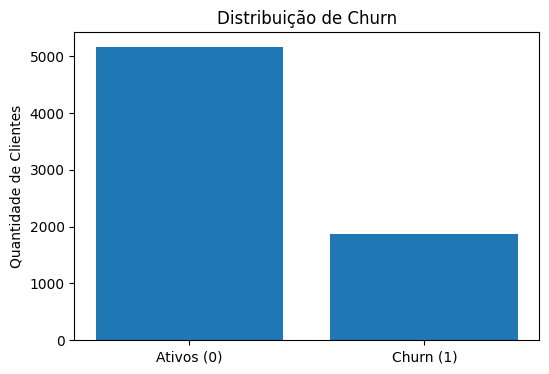

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(["Ativos (0)", "Churn (1)"], churn_counts.values)

plt.title("Distribuição de Churn")
plt.ylabel("Quantidade de Clientes")

plt.show()

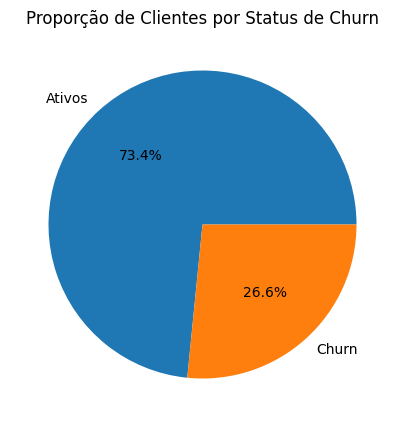

In [28]:
plt.figure(figsize=(5,5))

plt.pie(
    churn_counts.values,
    labels=["Ativos", "Churn"],
    autopct="%1.1f%%"
)

plt.title("Proporção de Clientes por Status de Churn")

plt.show()

In [30]:
import matplotlib.pyplot as plt

def churn_por_categoria(df, coluna):
    tabela = (
        df.groupby(coluna)["Churn"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )

    print(f"\n📊 Churn por {coluna}")
    display(tabela)

    plt.figure(figsize=(8,4))
    plt.bar(tabela.index.astype(str), tabela["mean"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Taxa de Churn")
    plt.title(f"Taxa de Churn por {coluna}")
    plt.show()


📊 Churn por customer.gender


,mean,count
customer.gender,,
Female,0.269595,3483
Male,0.262046,3549


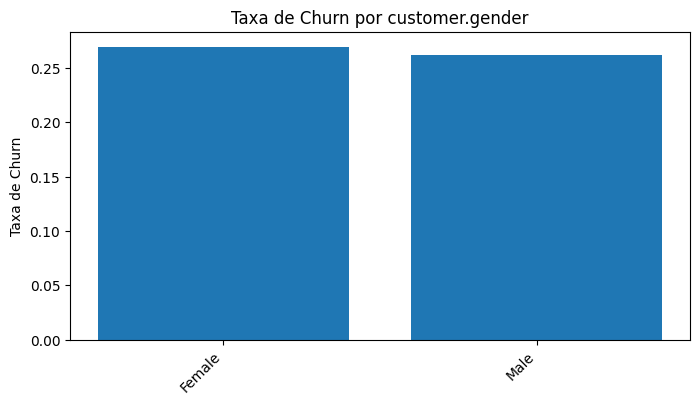

In [31]:
churn_por_categoria(df, "customer.gender")


📊 Churn por account.Contract


,mean,count
account.Contract,,
Month-to-month,0.427097,3875
One year,0.112772,1472
Two year,0.028487,1685


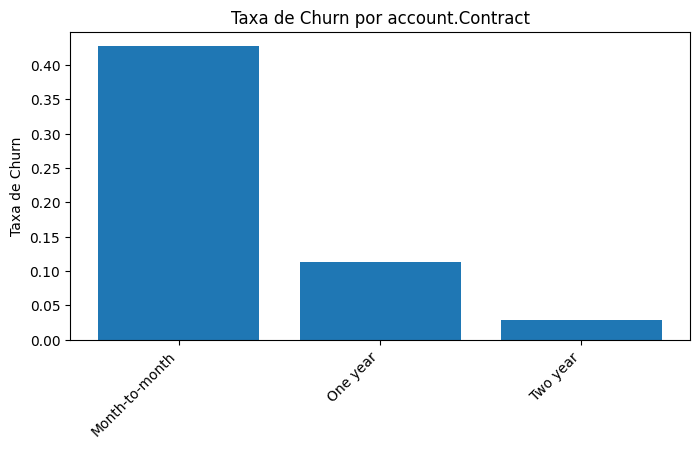

In [32]:
churn_por_categoria(df, "account.Contract")


📊 Churn por account.PaymentMethod


,mean,count
account.PaymentMethod,,
Electronic check,0.452854,2365
Mailed check,0.192020,1604
Bank transfer (automatic),0.167315,1542
Credit card (automatic),0.152531,1521


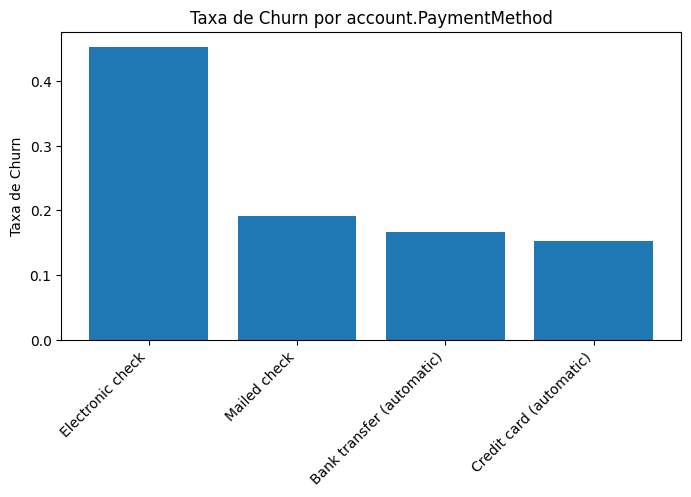

In [33]:
churn_por_categoria(df, "account.PaymentMethod")


📊 Churn por internet.InternetService


,mean,count
internet.InternetService,,
Fiber optic,0.418928,3096
DSL,0.189983,2416
No,0.074342,1520


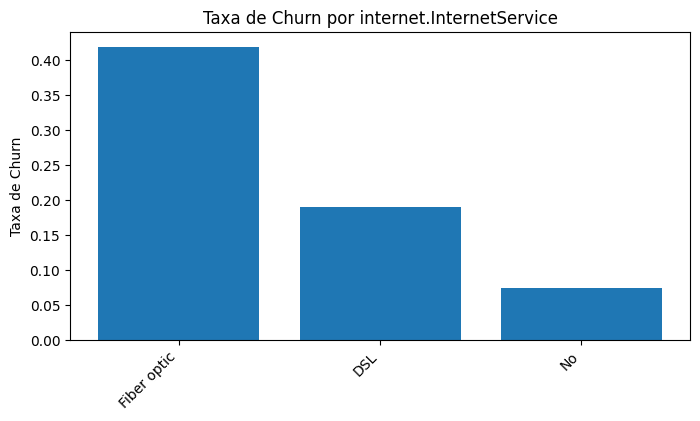

In [34]:
churn_por_categoria(df, "internet.InternetService")


📊 Churn por customer.SeniorCitizen


,mean,count
customer.SeniorCitizen,,
1,0.416813,1142
0,0.236503,5890


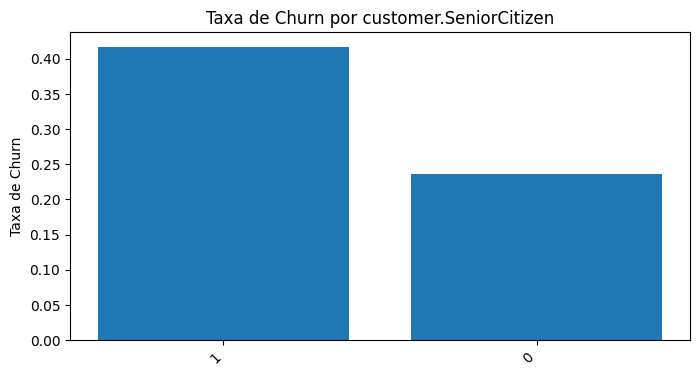

In [35]:
churn_por_categoria(df, "customer.SeniorCitizen")

<Figure size 600x400 with 0 Axes>

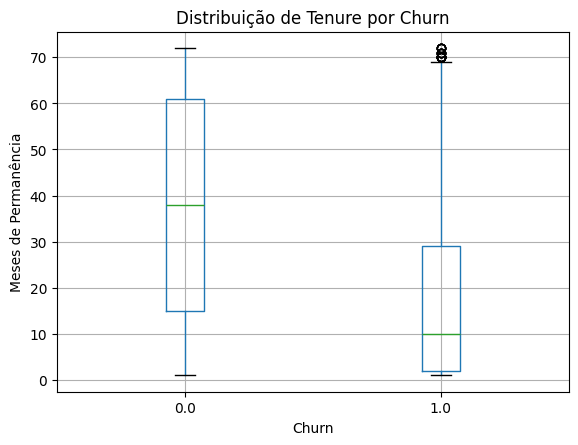

In [36]:
plt.figure(figsize=(6,4))

df.boxplot(column="customer.tenure", by="Churn")

plt.title("Distribuição de Tenure por Churn")
plt.suptitle("")
plt.ylabel("Meses de Permanência")

plt.show()

<Figure size 600x400 with 0 Axes>

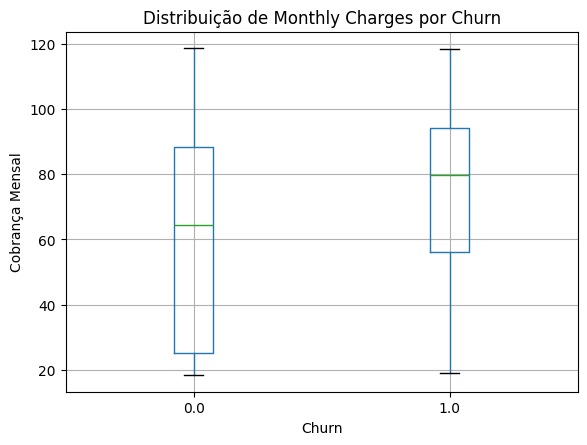

In [37]:
plt.figure(figsize=(6,4))

df.boxplot(column="account.Charges.Monthly", by="Churn")

plt.title("Distribuição de Monthly Charges por Churn")
plt.suptitle("")
plt.ylabel("Cobrança Mensal")

plt.show()

<Figure size 600x400 with 0 Axes>

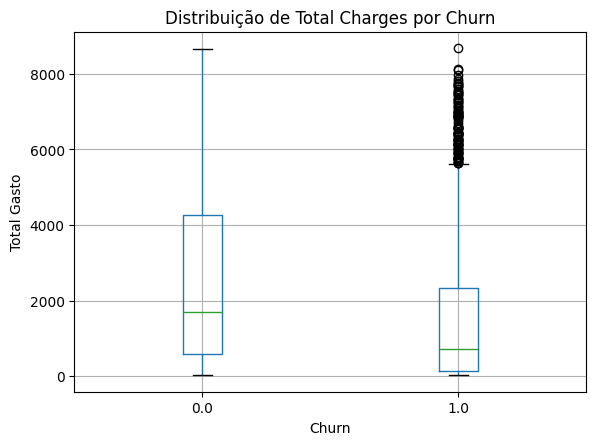

In [38]:
plt.figure(figsize=(6,4))

df.boxplot(column="account.Charges.Total", by="Churn")

plt.title("Distribuição de Total Charges por Churn")
plt.suptitle("")
plt.ylabel("Total Gasto")

plt.show()

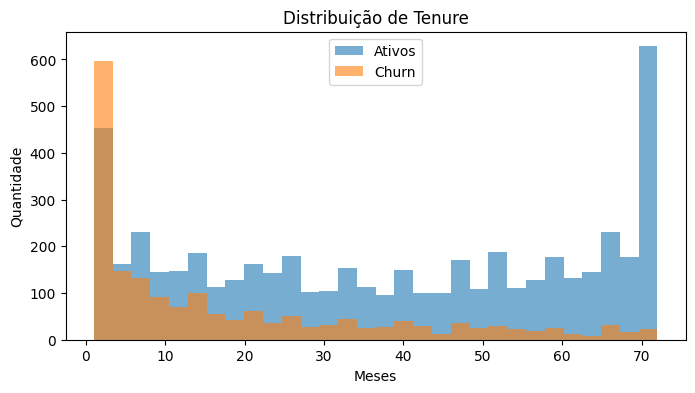

In [39]:
plt.figure(figsize=(8,4))

plt.hist(df[df["Churn"]==0]["customer.tenure"], bins=30, alpha=0.6, label="Ativos")
plt.hist(df[df["Churn"]==1]["customer.tenure"], bins=30, alpha=0.6, label="Churn")

plt.legend()
plt.title("Distribuição de Tenure")
plt.xlabel("Meses")
plt.ylabel("Quantidade")

plt.show()

In [40]:
df["tenure_faixa"] = pd.cut(
    df["customer.tenure"],
    bins=[0,6,12,24,48,72],
    labels=["0-6","7-12","13-24","25-48","49-72"]
)

df.groupby("tenure_faixa")["Churn"].mean()

/tmp/ipython-input-1239042945.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("tenure_faixa")["Churn"].mean()


,Churn
tenure_faixa,
0-6,0.533333
7-12,0.358865
13-24,0.287109
25-48,0.203890
49-72,0.095132


Atividade Extra


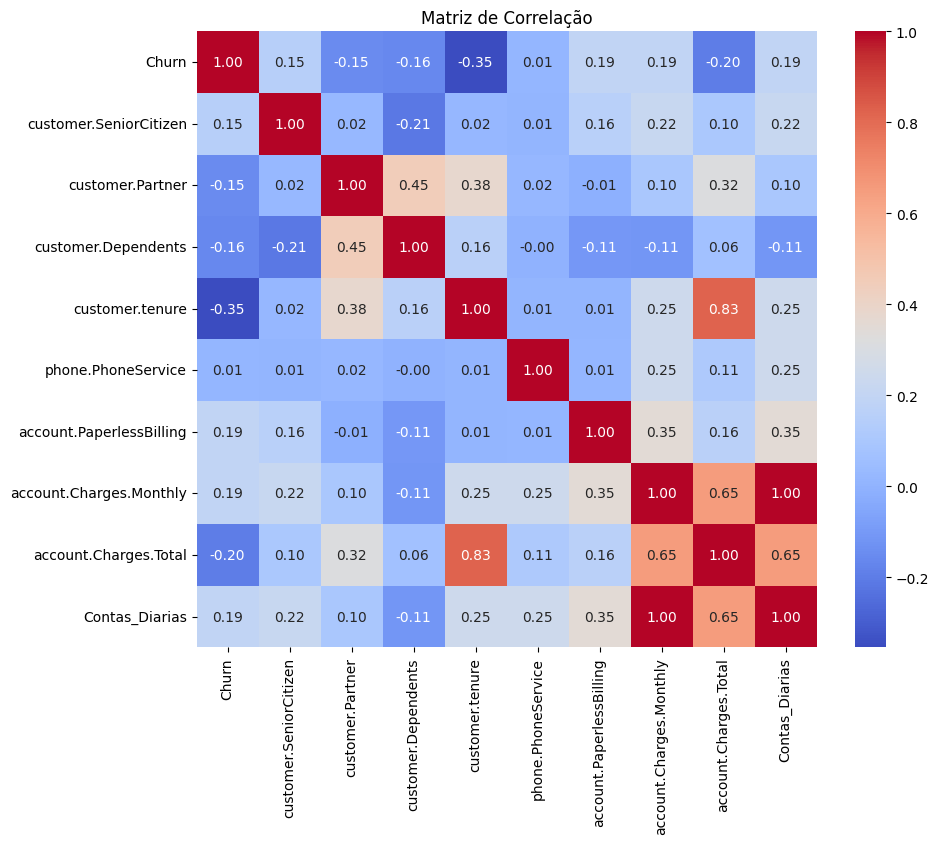

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas colunas numéricas
df_numeric = df.select_dtypes(include=["int64", "float64"])

# Matriz de correlação
corr_matrix = df_numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

In [43]:
df[["Contas_Diarias", "Churn"]].corr()

,Contas_Diarias,Churn
Contas_Diarias,1.000000,0.192858
Churn,0.192858,1.000000


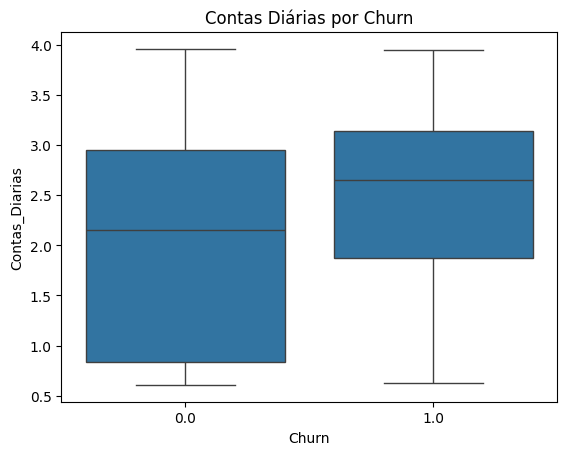

In [44]:
sns.boxplot(x="Churn", y="Contas_Diarias", data=df)
plt.title("Contas Diárias por Churn")
plt.show()

In [46]:
servicos = [
    "phone.PhoneService",
    "phone.MultipleLines",
    "internet.OnlineSecurity",
    "internet.OnlineBackup",
    "internet.DeviceProtection",
    "internet.TechSupport",
    "internet.StreamingTV",
    "internet.StreamingMovies"
]

# Columns that need to be mapped to 0/1
service_cols_to_map = [
    "phone.MultipleLines",
    "internet.OnlineSecurity",
    "internet.OnlineBackup",
    "internet.DeviceProtection",
    "internet.TechSupport",
    "internet.StreamingTV",
    "internet.StreamingMovies"
]

# Apply mapping for 'Yes', 'No', and 'No internet/phone service'
for col in service_cols_to_map:
    df[col] = df[col].map({"Yes": 1, "No": 0, "No internet service": 0, "No phone service": 0})

df["Qtd_Servicos"] = df[servicos].sum(axis=1)

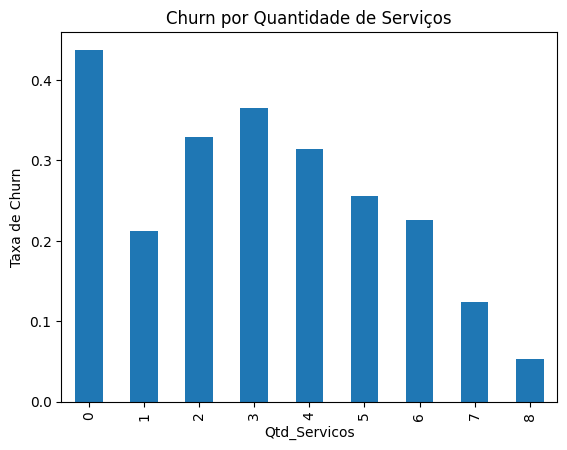

In [47]:
df.groupby("Qtd_Servicos")["Churn"].mean().plot(kind="bar")
plt.title("Churn por Quantidade de Serviços")
plt.ylabel("Taxa de Churn")
plt.show()

# **Relatório Final (Telecom X | Churn)**


1. Introdução

Este projeto tem como objetivo analisar o problema de evasão de clientes (Churn) na Telecom X, entendendo quais características de clientes e do serviço contratado estão mais associadas ao cancelamento.
A empresa enfrenta um churn relevante e precisa identificar padrões que ajudem a direcionar ações de retenção, melhorar a experiência do cliente e apoiar o time de Data Science na construção de modelos preditivos.

Definição do alvo (target):

Churn = 1 → cliente cancelou

Churn = 0 → cliente permaneceu ativo

2. Limpeza e Tratamento de Dados (ETL)
2.1 Extração (E)

Os dados foram carregados diretamente do arquivo JSON disponibilizado via GitHub (formato API/RAW).

O JSON foi convertido para um DataFrame Pandas com pd.json_normalize(), resultando em uma base tabular pronta para análise.

2.2 Transformação (T)

Foram executadas checagens e ajustes para garantir qualidade analítica:

Tipos de dados e estrutura:

Dataset com 7.267 linhas e 21 colunas (estrutura achatada com prefixos customer., internet., account. etc.).

Valores ausentes e duplicados:

Checagem de nulos e duplicados por customerID.

Resultado: 0 valores ausentes e 0 duplicados após validações.

Correção de tipagem (Total Charges):

A coluna account.Charges.Total estava em formato object e foi convertida para numérico com pd.to_numeric(errors="coerce").

Após a conversão, a base permaneceu consistente (sem perdas relevantes).

Criação da variável adicional (Contas_Diarias):

Criada a coluna Contas_Diarias a partir do faturamento mensal:
Contas_Diarias = account.Charges.Monthly / 30

Objetivo: visão mais granular do custo/valor do cliente ao longo do tempo.

2.3 Carga (L)

O dataset final foi mantido em DataFrame já limpo e pronto para EDA e etapas futuras de modelagem.

3. Análise Exploratória de Dados (EDA)

Nesta etapa, foram realizadas análises descritivas e comparativas entre clientes que churnaram vs. clientes ativos.

3.1 Distribuição do Churn

Taxa de churn geral: 26,6%

Proporção de clientes: ~73,4% ativos vs. 26,6% churn

Gráficos gerados: barras (contagem) e pizza (proporção) para visualizar a distribuição do target.

3.2 Variáveis Numéricas (comparação por Churn)

Foram analisadas principalmente:

customer.tenure (tempo de contrato)

account.Charges.Monthly (cobrança mensal)

account.Charges.Total (total gasto)

Contas_Diarias (cobrança diária estimada)

Tenure (tempo de contrato)

Clientes churn: média ~18 meses e mediana ~10 meses

Clientes ativos: média ~38 meses e mediana ~38 meses

Visualizações: histograma comparativo e boxplot por churn.

Monthly Charges (cobrança mensal)

Clientes churn pagam mais em média:

Ativos: ~61,3

Churn: ~74,4

Visualizações: boxplot por churn.

Total Charges (total gasto)

Ativos apresentam total gasto maior (efeito direto do maior tempo de permanência).

Visualização: boxplot por churn.

3.3 Churn por faixas de Tenure

A base foi segmentada em faixas de permanência:

0–6 meses → 53,3% churn

7–12 meses → 35,9%

13–24 meses → 28,7%

25–48 meses → 20,4%

49–72 meses → 9,5%

Insight: o churn cai progressivamente conforme aumenta o tempo de relacionamento, indicando alta vulnerabilidade nos primeiros meses.

3.4 Variáveis Categóricas (comparação por Churn)

Foram avaliadas variáveis como gênero, contrato, método de pagamento e Senior Citizen.

Gênero (customer.gender)

Female: ~27,0% churn

Male: ~26,2% churn

Diferença pequena → baixo poder explicativo para churn.

Tipo de contrato (account.Contract)

Month-to-month → ~43% churn (mais alto)

One year → ~11% churn

Two year → ~2,8% churn (mais baixo)

Contratos mensais são muito mais instáveis, sugerindo forte associação com churn.

Método de pagamento (account.PaymentMethod)

Electronic check → 45,3% churn (mais alto)

Mailed check → ~19,2%

Bank transfer (automatic) → ~16,7%

Credit card (automatic) → ~15,3% (mais baixo)

Pagamentos automáticos apresentam menor churn; electronic check se destaca como risco.

Senior Citizen (customer.SeniorCitizen)

SeniorCitizen=1 → 41,7% churn

SeniorCitizen=0 → 23,7% churn

Perfil sênior possui maior risco de churn — pode exigir estratégia específica.

4. Conclusões e Insights (principais achados)

Churn geral de 26,6% indica um nível relevante de evasão.

Tenure é o principal driver: churn é muito mais alto nos primeiros meses (0–6 meses supera 50%).

Contrato Month-to-month é altamente associado ao churn, enquanto contratos longos reduzem drasticamente a evasão.

Método de pagamento “Electronic check” tem churn muito superior, sugerindo menor comprometimento ou maior fricção.

Senior Citizen apresenta churn elevado, indicando necessidade de atenção em experiência/suporte/oferta.

Clientes com maior cobrança mensal (Monthly Charges) tendem a churnar mais → possível sensibilidade a preço ou percepção de valor.

Esses insights ajudam a direcionar ações de retenção e também oferecem variáveis importantes para modelos preditivos futuros (feature importance).

5. Recomendações (ações sugeridas)

Com base nos padrões identificados:

(A) Retenção precoce (0–6 meses)

Criar ações de onboarding e acompanhamento nos primeiros 90 dias.

Ofertas de valor percebido (benefícios, upgrades, suporte) logo no início.

Monitorar sinais de risco: tenure baixo + mensalidade alta + payment method não automático.

(B) Incentivar migração de contrato

Campanhas para migrar clientes Month-to-month → One year/Two year com:

descontos progressivos

bônus de serviços (streaming, suporte premium)

fidelização com benefício claro

(C) Reduzir churn no “Electronic check”

Incentivar migração para pagamento automático (cartão/transferência automática).

Oferecer benefícios para adesão a autopay (ex.: desconto no próximo mês).

(D) Estratégia dedicada para Senior Citizens

Melhorar UX e suporte (canais mais acessíveis, comunicação mais clara).

Planos com melhor custo-benefício e suporte técnico simplificado.

(E) Revisão de pricing / valor percebido

Clientes com mensalidades mais altas churnam mais:

avaliar percepção de qualidade do serviço

oferecer planos alternativos (downgrade controlado)

bundles para justificar preço


Observou-se uma relação inversa entre quantidade de serviços contratados e taxa de churn. Clientes com poucos serviços apresentam maior probabilidade de cancelamento, enquanto clientes com múltiplos serviços demonstram maior retenção.

Esse padrão sugere que maior engajamento com o portfólio da empresa aumenta o vínculo e reduz a evasão.


6. Encerramento

A análise exploratória identificou fatores-chave associados à evasão e gera uma base sólida para:

construção de modelos preditivos (classificação churn)

definição de políticas de retenção

priorização de segmentos com maior risco

In [41]:
churn_rate = df["Churn"].mean()
print(f"Churn geral: {churn_rate:.2%}")

# Tenure buckets
df["tenure_faixa"] = pd.cut(df["customer.tenure"], bins=[0,6,12,24,48,72], labels=["0-6","7-12","13-24","25-48","49-72"])
print("\nChurn por faixa de tenure:")
print((df.groupby("tenure_faixa")["Churn"].mean()*100).round(1))

print("\nChurn por contrato:")
print((df.groupby("account.Contract")["Churn"].mean()*100).round(1).sort_values(ascending=False))

print("\nChurn por método de pagamento:")
print((df.groupby("account.PaymentMethod")["Churn"].mean()*100).round(1).sort_values(ascending=False))

print("\nChurn por SeniorCitizen:")
print((df.groupby("customer.SeniorCitizen")["Churn"].mean()*100).round(1).sort_values(ascending=False))

Churn geral: 26.58%

Churn por faixa de tenure:
tenure_faixa
0-6      53.3
7-12     35.9
13-24    28.7
25-48    20.4
49-72     9.5
Name: Churn, dtype: float64

Churn por contrato:
account.Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

Churn por método de pagamento:
account.PaymentMethod
Electronic check             45.3
Mailed check                 19.2
Bank transfer (automatic)    16.7
Credit card (automatic)      15.3
Name: Churn, dtype: float64

Churn por SeniorCitizen:
customer.SeniorCitizen
1    41.7
0    23.7
Name: Churn, dtype: float64


/tmp/ipython-input-2054150384.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print((df.groupby("tenure_faixa")["Churn"].mean()*100).round(1))
